In [161]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import statistics as sts 
import streamlit as st 
import joblib
import time 
import warnings
from matplotlib import pyplot as plt 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,PowerTransformer,PolynomialFeatures
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,median_absolute_error,root_mean_squared_error

In [162]:
warnings.filterwarnings("ignore")

In [163]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred14\insurance.csv",encoding_errors='ignore')

In [164]:
df1.shape

(1338, 7)

In [165]:
df1.ndim

2

In [166]:
df1.size

9366

In [167]:
df1.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [168]:
df1.drop_duplicates(inplace=True)

In [169]:
df1.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [170]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [171]:
df1.sample(10)

,age,sex,bmi,children,smoker,region,charges
19,30,male,35.30,0,yes,southwest,36837.4670
336,60,male,25.74,0,no,southeast,12142.5786
398,64,male,25.60,2,no,southwest,14988.4320
1259,52,female,23.18,0,no,northeast,10197.7722
845,60,female,32.45,0,yes,southeast,45008.9555
1066,48,male,37.29,2,no,southeast,8978.1851
64,20,female,22.42,0,yes,northwest,14711.7438
550,63,male,30.80,0,no,southwest,13390.5590
1217,29,male,37.29,2,no,southeast,4058.1161
103,61,female,29.92,3,yes,southeast,30942.1918


In [172]:
df1['region'].unique().tolist()

['southwest', 'southeast', 'northwest', 'northeast']

In [173]:
region_mapping={
    'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3
}
df1['region_encoded']=df1['region'].map(region_mapping)

In [174]:
df1['smoker'].value_counts().to_json()

'{"no":1063,"yes":274}'

In [175]:
smoker_mapping={
    "yes":1,
    "no":0
}

df1['smoker_enocoded']=df1['smoker'].map(smoker_mapping)

In [176]:
df1['sex'].value_counts().to_dict()

{'male': 675, 'female': 662}

In [177]:
gender_mapping={
   'male': 0, 'female': 1 
}

df1['sex_encoded']=df1['sex'].map(gender_mapping)

In [178]:
df1.sample(10)

,age,sex,bmi,children,smoker,region,charges,region_encoded,smoker_enocoded,sex_encoded
960,19,female,39.615,1,no,northwest,2730.10785,2,0,1
315,52,male,33.250,0,no,northeast,9722.76950,3,0,0
1112,48,female,25.850,3,yes,southeast,24180.93350,1,1,1
247,24,male,35.860,0,no,southeast,1986.93340,1,0,0
689,27,male,31.130,1,yes,southeast,34806.46770,1,1,0
143,29,male,29.735,2,no,northwest,18157.87600,2,0,0
280,40,female,28.120,1,yes,northeast,22331.56680,3,1,1
469,18,female,24.090,1,no,southeast,2201.09710,1,0,1
1080,18,male,21.780,2,no,southeast,11884.04858,1,0,0
391,19,female,37.430,0,no,northwest,2138.07070,2,0,1


In [179]:
df2=df1.copy()

In [180]:
df2.drop(columns=['sex','smoker','region'],axis=1,inplace=True)

In [181]:
df2.sample(10)

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
267,59,32.395,3,14590.63205,3,0,1
1328,23,24.225,2,22395.74424,3,0,1
450,39,29.600,4,7512.26700,0,0,0
326,27,23.210,1,3561.88890,1,0,1
851,61,32.300,2,14119.62000,2,0,0
59,34,37.335,2,5989.52365,2,0,1
1311,33,26.695,0,4571.41305,2,0,1
694,27,34.800,1,3577.99900,0,0,1
455,59,37.400,0,21797.00040,0,0,0
526,19,30.590,2,24059.68019,2,0,1


In [182]:
df2.describe().round(2)

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
count,1337.00,1337.00,1337.00,1337.00,1337.00,1337.0,1337.0
mean,39.22,30.66,1.10,13279.12,1.48,0.2,0.5
std,14.04,6.10,1.21,12110.36,1.11,0.4,0.5
min,18.00,15.96,0.00,1121.87,0.00,0.0,0.0
25%,27.00,26.29,0.00,4746.34,1.00,0.0,0.0
50%,39.00,30.40,1.00,9386.16,1.00,0.0,0.0
75%,51.00,34.70,2.00,16657.72,2.00,0.0,1.0
max,64.00,53.13,5.00,63770.43,3.00,1.0,1.0


In [183]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1337 non-null   int64  
 1   bmi              1337 non-null   float64
 2   children         1337 non-null   int64  
 3   charges          1337 non-null   float64
 4   region_encoded   1337 non-null   int64  
 5   smoker_enocoded  1337 non-null   int64  
 6   sex_encoded      1337 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 83.6 KB


In [184]:
df2.columns

Index(['age', 'bmi', 'children', 'charges', 'region_encoded',
       'smoker_enocoded', 'sex_encoded'],
      dtype='object')

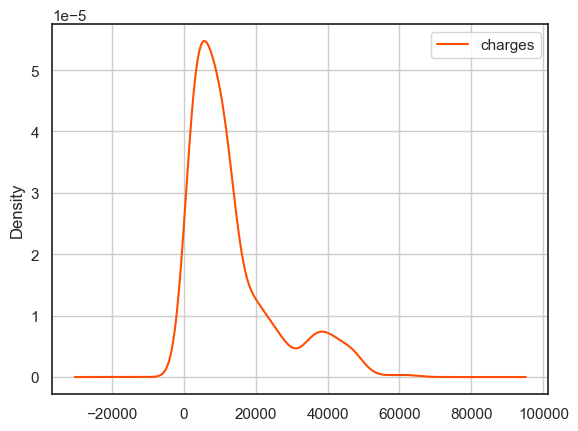

In [185]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
df2['charges'].plot(kind='kde',color='#ff4d01',legend='charges')
plt.savefig("p1.png",dpi=1000)
plt.grid(True)
plt.show()

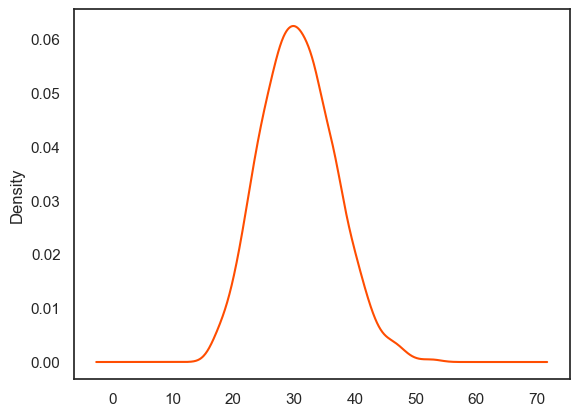

In [186]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
df2['bmi'].plot(kind='kde',color='#ff4d01')
plt.show()

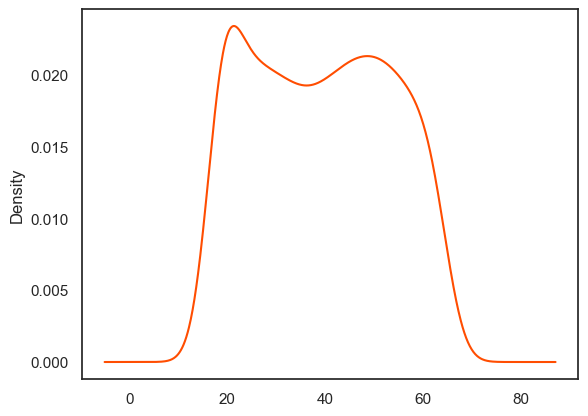

In [187]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
df2['age'].plot(kind='kde',color='#ff4d01')
plt.show()

age --> no anomolies found
bmi --> [116, 286, 401, 543, 847, 860, 1047, 1088, 1317] 
 9


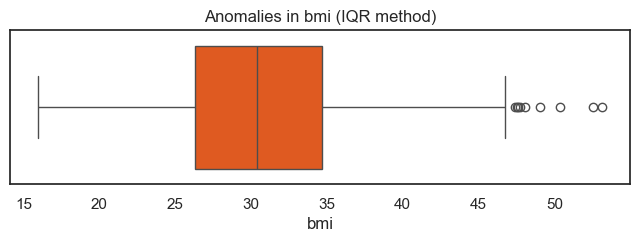

old shape is (1337, 7) and new shape (1328, 7)


In [188]:
class Anomolies_class:
    def __init__(self,data):
        self.data=data
    
    def anomolies_section(self,column):
        Q1=self.data[column].quantile(0.25)
        Q3=self.data[column].quantile(0.75)
        IQR=Q3-Q1
        leftbound=Q1-1.5*IQR
        rightbound=Q3+1.5*IQR 
        mask=(self.data[column]<leftbound) | (self.data[column]>rightbound)
        anomolies_index=self.data[mask].index.to_list()
        anomolies_data=self.data.loc[anomolies_index,column].to_list()
        return anomolies_index, list(anomolies_data)
    
numeric_col=df2.select_dtypes(include='number',exclude='object').columns
anomolies_instance=Anomolies_class(df2)
anomolies_store_index=set()
counter=0
columns_to_check=['age','bmi']
for each_col in columns_to_check:
    ano_index,ano_data=anomolies_instance.anomolies_section(each_col)
    count_index=len(ano_index)
    if ano_index:
        print(f"{each_col} --> {ano_index} \n {count_index}")
        plt.figure(figsize=(8,2))
        sns.boxplot(data=df2, x=each_col)
        plt.title(f'Anomalies in {each_col} (IQR method)')
        plt.savefig(f"{each_col}.png",dpi=100)
        plt.show()
        anomolies_store_index.update(ano_index)
    else:
        print(f"{each_col} --> no anomolies found")

df3=df2.drop(list(anomolies_store_index),axis=0)
print(f"old shape is {df2.shape} and new shape {df3.shape}")

In [189]:
# skew_data=PowerTransformer(method='yeo-johnson')
# df2[['age','bmi']]=skew_data.fit_transform(df2[['age','bmi']])

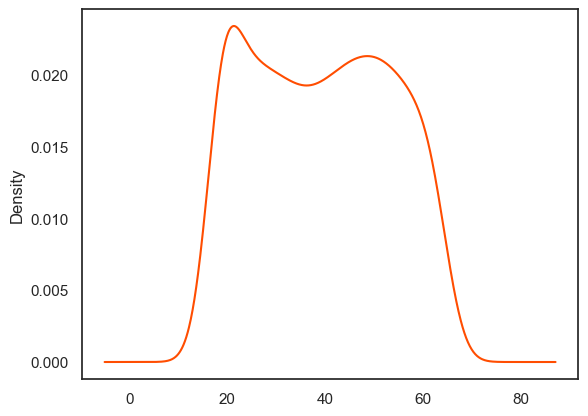

In [190]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
df2['age'].plot(kind='kde',color='#ff4d01')
plt.show()

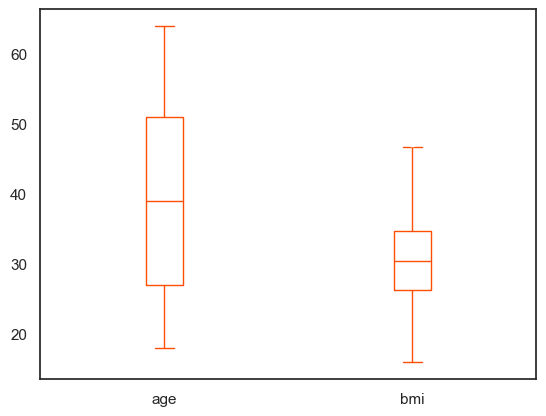

In [191]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
df2[['age','bmi']].plot(kind='box',color='#ff4d01')
plt.savefig("p2.png",dpi=1000)
plt.show()

In [192]:
sper=df3.corr(method='spearman').round(2)
sper

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
age,1.00,0.11,0.06,0.53,-0.00,-0.03,0.02
bmi,0.11,1.00,0.02,0.12,-0.15,-0.00,-0.04
children,0.06,0.02,1.00,0.13,-0.01,0.02,-0.02
charges,0.53,0.12,0.13,1.00,0.05,0.66,-0.01
region_encoded,-0.00,-0.15,-0.01,0.05,1.00,0.01,0.00
smoker_enocoded,-0.03,-0.00,0.02,0.66,0.01,1.00,-0.08
sex_encoded,0.02,-0.04,-0.02,-0.01,0.00,-0.08,1.00


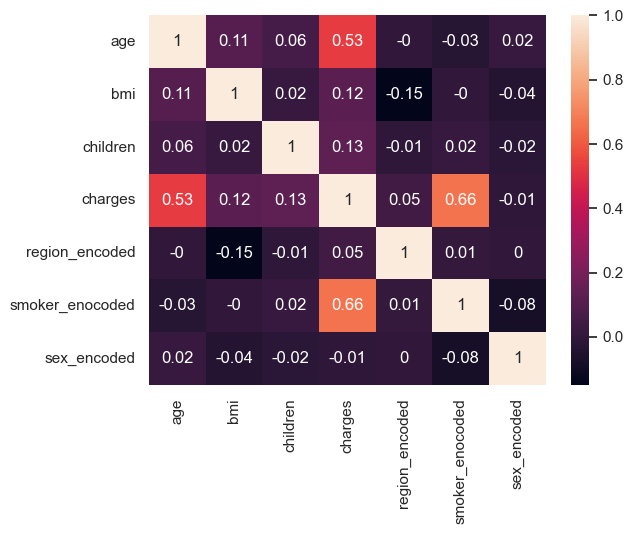

In [193]:
sns.heatmap(sper,annot=True)
plt.show()

In [194]:
pear=df3.corr(method='pearson').round(2)
pear

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
age,1.00,0.11,0.04,0.30,-0.00,-0.03,0.02
bmi,0.11,1.00,0.02,0.19,-0.16,-0.00,-0.04
children,0.04,0.02,1.00,0.07,-0.02,0.01,-0.02
charges,0.30,0.19,0.07,1.00,0.01,0.79,-0.06
region_encoded,-0.00,-0.16,-0.02,0.01,1.00,0.01,0.00
smoker_enocoded,-0.03,-0.00,0.01,0.79,0.01,1.00,-0.08
sex_encoded,0.02,-0.04,-0.02,-0.06,0.00,-0.08,1.00


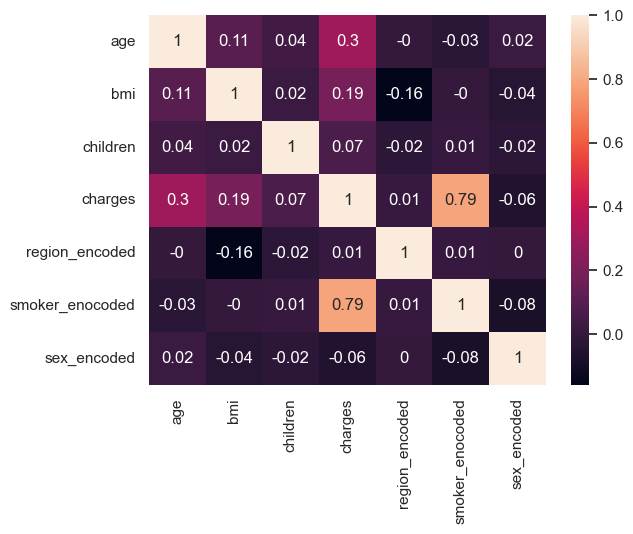

In [195]:
sns.heatmap(pear,annot=True)
plt.show()

In [196]:
df3.describe()

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
count,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000
mean,39.219127,30.537308,1.097139,13221.047810,1.486446,0.204066,0.496235
std,14.042170,5.922176,1.208008,11997.547468,1.106859,0.403169,0.500174
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000
25%,27.000000,26.220000,0.000000,4744.325050,1.000000,0.000000,0.000000
50%,39.000000,30.300000,1.000000,9369.615750,1.000000,0.000000,0.000000
75%,51.000000,34.488750,2.000000,16604.302645,2.000000,0.000000,1.000000
max,64.000000,46.750000,5.000000,62592.873090,3.000000,1.000000,1.000000


In [197]:
df3.sample(2)

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
9,60,25.840,0,28923.13692,2,0,1
1192,58,32.395,1,13019.16105,3,0,1


In [198]:
# df2[['age','bmi']]=skew_data.inverse_transform(df2[['age','bmi']])

In [199]:
df3.columns

Index(['age', 'bmi', 'children', 'charges', 'region_encoded',
       'smoker_enocoded', 'sex_encoded'],
      dtype='object')

In [200]:
x=df3[['age', 'bmi', 'children', 'region_encoded',
       'smoker_enocoded', 'sex_encoded']]
y=df3['charges'].squeeze()

In [201]:
df3.columns.tolist()

['age',
 'bmi',
 'children',
 'charges',
 'region_encoded',
 'smoker_enocoded',
 'sex_encoded']

In [202]:
df3.describe()

,age,bmi,children,charges,region_encoded,smoker_enocoded,sex_encoded
count,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000
mean,39.219127,30.537308,1.097139,13221.047810,1.486446,0.204066,0.496235
std,14.042170,5.922176,1.208008,11997.547468,1.106859,0.403169,0.500174
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000
25%,27.000000,26.220000,0.000000,4744.325050,1.000000,0.000000,0.000000
50%,39.000000,30.300000,1.000000,9369.615750,1.000000,0.000000,0.000000
75%,51.000000,34.488750,2.000000,16604.302645,2.000000,0.000000,1.000000
max,64.000000,46.750000,5.000000,62592.873090,3.000000,1.000000,1.000000


In [203]:
features_selection=SelectKBest(score_func=f_regression,k=4)
features_selection

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...001E8DEF8F880>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",4


In [204]:
features_selection.fit_transform(x,y)

array([[19.  , 27.9 ,  0.  ,  1.  ],
       [18.  , 33.77,  1.  ,  0.  ],
       [28.  , 33.  ,  3.  ,  0.  ],
       ...,
       [18.  , 36.85,  0.  ,  0.  ],
       [21.  , 25.8 ,  0.  ,  0.  ],
       [61.  , 29.07,  0.  ,  1.  ]], shape=(1328, 4))

In [205]:
columns_Selection=x.columns[features_selection.get_support()]
columns_Selection

Index(['age', 'bmi', 'children', 'smoker_enocoded'], dtype='object')

In [206]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [207]:
Linear_reg=LinearRegression(n_jobs=-1)
Linear_reg


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [208]:
poly=PolynomialFeatures(degree=2,include_bias=False)
poly
poly1=PolynomialFeatures(degree=3,include_bias=False)
poly1


,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [209]:
lasso=Lasso(alpha=1)
lasso

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [210]:
decesion=DecisionTreeRegressor(splitter='best',max_depth=10,min_samples_leaf=20,max_features='log2',criterion='absolute_error',min_samples_split=20)
decesion

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"

In [211]:
random=RandomForestRegressor(n_jobs=-1,max_depth=10,max_features=30,min_samples_leaf=20,min_samples_split=30,criterion='absolute_error',n_estimators=10)
random

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",30
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [212]:
knn=KNeighborsRegressor(n_neighbors=4,n_jobs=-1)
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [213]:
from sklearn.pipeline import Pipeline

# Create proper Pipeline objects (steps must be list of tuples)
pipe1 = Pipeline(steps=[
    ('linear_reg', Linear_reg)
])

pipe2 = Pipeline(steps=[
    ('poly', poly),
    ('linear_reg', Linear_reg)
])

pipe3 = Pipeline(steps=[
    ('poly1', poly1),
    ('linear_reg', Linear_reg)
])

pipe4 = Pipeline(steps=[
    ('lasso', lasso)
])

pipe5 = Pipeline(steps=[
    ('tree', decesion)
])

pipe6 = Pipeline(steps=[
    ('random', random)
])

pipe7 = Pipeline(steps=[
    ('knn', knn)
])

# Map model names to actual Pipeline objects
model_dict = {
    "LinearRegression": pipe1,
    "Polynomial (degree 2)": pipe2,
    "Polynomial (degree 3)": pipe3,
    "Lasso": pipe4,
    "DecisionTreeRegressor": pipe5,
    "RandomForestRegressor": pipe6,
    "KNeighborsRegressor": pipe7
}


for name, model in model_dict.items():
    print(f"model name is : {name}")
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(r2_score(y_test,y_pred))
    # print(model.score(x_test,y_test))
    print(y_pred)
    


model name is : LinearRegression
0.7424341701251109
[29037.25089609  8795.48454153 34206.31687996  7084.66527576
 23582.95106532 34171.8299426  29642.7594241   9637.8696224
  8118.15886325 33970.39521626  2714.58077276  7285.8911757
  7126.85796311  6315.58135725 26253.49144457 27669.40713511
 10319.24614043  9168.79529062 33079.91657213 10173.96372382
 13101.4511269  27899.86787755 32995.84875727  8401.71549566
 14546.13983563  6064.02498871  4967.54222607  3988.30707359
 33572.27209551   682.73223507 27049.8181049   7286.55454387
  6232.62225613 15761.86862754  2162.73640216 30127.44816957
 33863.94374862 14174.52467627 11993.53676245  5409.36111573
 25128.96790903 36148.13015161 27370.38739301 10882.86595676
 15603.36340879  1924.25270186  8490.93107708 13101.71433326
  5465.52722574 10171.40190333 12604.6015308  31402.73926076
 10529.5138517   7942.79674508 26878.50591574  7422.05945799
 18359.76960764 38768.65496789  3471.64666512   300.26772863
  -533.55442398 13647.98749049  927

In [214]:
Linear_reg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# For degree 2 model
pipe2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_reg', LinearRegression())
])
pipe2.fit(x_train, y_train)  # X_train = raw features (6 columns)

# For degree 3 model
pipe3 = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('linear_reg', LinearRegression())
])
pipe3.fit(x_train, y_train)
joblib.dump(pipe3, "poly1.joblib") 


['poly1.joblib']

In [229]:
joblib.dump(pipe2, "poly.joblib") 

['poly.joblib']

In [217]:
pipe3.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('linear_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [218]:
decesion.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"

In [219]:
random.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",30
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [220]:
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [221]:
joblib.dump(Linear_reg,"Linear.joblib")

['Linear.joblib']

In [222]:
joblib.dump(poly,"poly.joblib")

['poly.joblib']

In [223]:
joblib.dump(poly1,"poly1.joblib")

['poly1.joblib']

In [224]:
joblib.dump(decesion,"decesion.joblib")

['decesion.joblib']

In [225]:
joblib.dump(random,'ran.joblib')

['ran.joblib']

In [226]:
joblib.dump(knn,"knn.joblib")

['knn.joblib']

In [227]:
joblib.dump(lasso,"lasso.joblib")

['lasso.joblib']